In [1]:
# Cell 1: Imports
import os
import numpy as np
from tqdm import tqdm
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.cross_decomposition import PLSRegression

In [2]:
# Cell 2: Configuration
biweek_folder = "processed_data_biweekly_11"  # Change as needed
modalities = ["S2L2A", "S1GRD", "CDL", "DEM", "WEATHER"]  # Update as needed
label_folder = "yield_geotiffs"

In [3]:
# Cell 3: Utility to load and flatten one modality
def load_and_flatten(modality_folder, file_name):
    arr = np.load(os.path.join(modality_folder, file_name))  # (T, C, H, W)
    arr = arr.reshape(arr.shape[0], arr.shape[1], -1)  # (T, C, H*W)
    arr = arr.transpose(2, 0, 1).reshape(-1, arr.shape[0]*arr.shape[1])  # (H*W, T*C)
    return arr

In [5]:
# Cell 4: Read split files
def read_split(split_path):
    with open(split_path) as f:
        return [line.strip() + ".npy" for line in f if line.strip()]

splits = {}
for split in ["train", "val", "test"]:
    split_file = os.path.join(biweek_folder, f"{split}.txt")
    if not os.path.exists(split_file):
        split_file = os.path.join(biweek_folder, split, f"{split}.txt")  # fallback if in subfolder
    splits[split] = read_split(split_file)

modal_paths = {m: os.path.join(biweek_folder, m) for m in modalities}
label_path = os.path.join(biweek_folder, label_folder)

def build_X_y(file_names):
    X_list, y_list = [], []
    for fname in tqdm(file_names):
        # Load and flatten all modalities
        feats = []
        skip = False
        for m in modalities:
            mfile = os.path.join(modal_paths[m], fname)
            if not os.path.exists(mfile):
                skip = True
                break
            arr = np.load(mfile)  # (T, C, H, W)
            arr = arr.reshape(arr.shape[0], arr.shape[1], -1)  # (T, C, H*W)
            arr = arr.transpose(2, 0, 1).reshape(-1, arr.shape[0]*arr.shape[1])  # (H*W, T*C)
            feats.append(arr)
        if skip:
            continue
        X = np.concatenate(feats, axis=1)  # (H*W, total_features)
        # Load and flatten label
        y = np.load(os.path.join(label_path, fname))  # (H, W) or (1, H, W)
        if y.ndim == 3:
            y = y.squeeze(0)
        y = y.flatten()
        # Remove nan or invalid pixels
        mask = np.isfinite(y)
        X = X[mask]
        y = y[mask]
        X_list.append(X)
        y_list.append(y)
    if X_list:
        X = np.concatenate(X_list, axis=0)
        y = np.concatenate(y_list, axis=0)
    else:
        X = np.empty((0, 1))
        y = np.empty((0,))
    # Drop samples where y == 0
    nonzero_mask = y != 0
    X = X[nonzero_mask]
    y = y[nonzero_mask]
    return X, y

In [6]:
# Cell 5: Build splits and train/validate/test
print("Loading train data...")
X_train, y_train = build_X_y(splits["train"])
print("Loading val data...")
X_val, y_val = build_X_y(splits["val"])
print("Loading test data...")
X_test, y_test = build_X_y(splits["test"])

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# Optionally, concatenate train and val for more data
X_trainval = np.concatenate([X_train, X_val], axis=0)
y_trainval = np.concatenate([y_train, y_val], axis=0)

Loading train data...


100%|██████████| 196/196 [00:07<00:00, 27.26it/s]


Loading val data...


100%|██████████| 56/56 [00:01<00:00, 42.77it/s]


Loading test data...


100%|██████████| 29/29 [00:00<00:00, 130.71it/s]


Train: (8686105, 23), Val: (2511564, 23), Test: (1247136, 23)


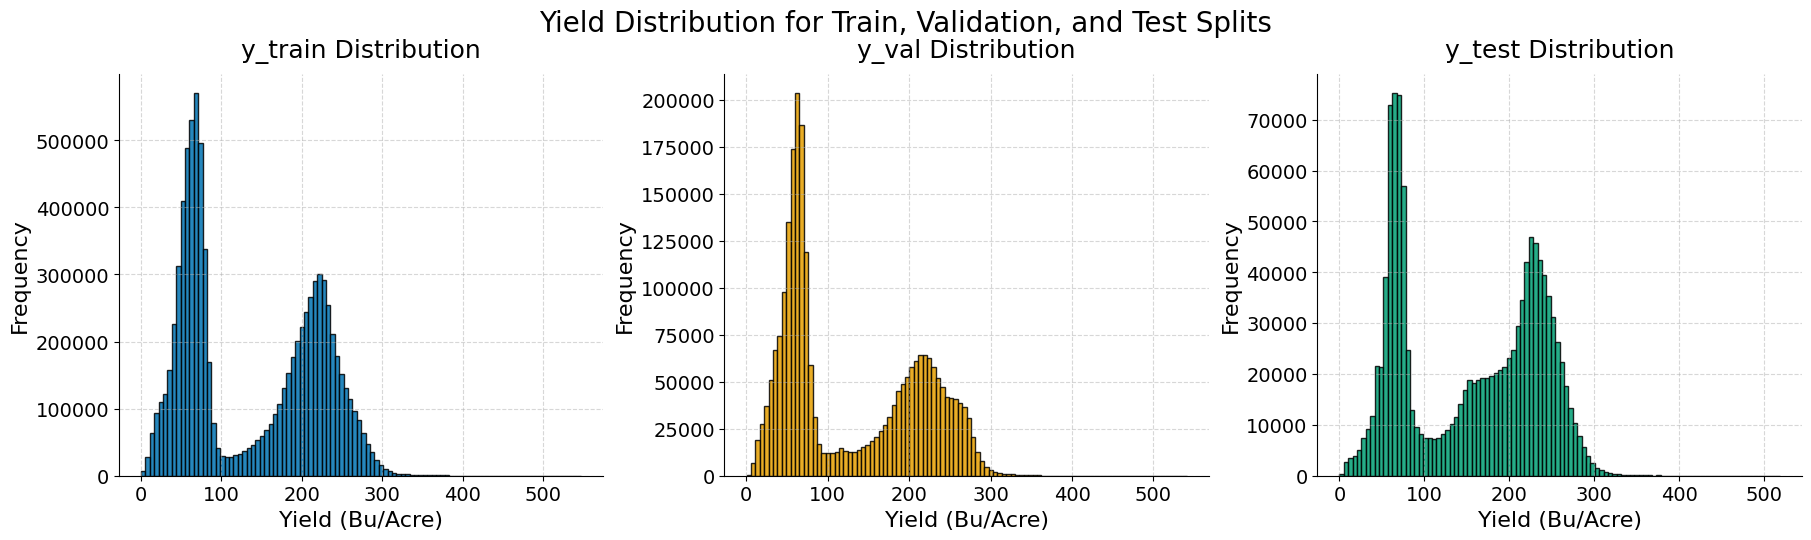

In [8]:
import matplotlib.pyplot as plt

# Colorblind-friendly palette (blue, orange, green)
cb_colors = ['#0072B2', '#E69F00', '#009E73']

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

splits = [
    (y_train, 'y_train', cb_colors[0]),
    (y_val, 'y_val', cb_colors[1]),
    (y_test, 'y_test', cb_colors[2])
]

for ax, (y, label, color) in zip(axes, splits):
    ax.hist(y, bins=100, color=color, alpha=0.85, edgecolor='black')
    ax.set_title(f'{label} Distribution', fontsize=18, pad=12)
    ax.set_xlabel('Yield (Bu/Acre)', fontsize=16)
    ax.set_ylabel('Frequency', fontsize=16)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.tick_params(axis='both', which='major', labelsize=14)
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Yield Distribution for Train, Validation, and Test Splits', fontsize=20, y=1.05)
plt.savefig('yield_distribution_hist.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [22]:
# --- Random Forest ---
rf = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
y_pred_val_rf = rf.predict(X_val)
y_pred_train_rf = rf.predict(X_train)

print("Random Forest TRAIN R2:", r2_score(y_train, y_pred_train_rf))
print("Random Forest TRAIN RMSE:", root_mean_squared_error(y_train, y_pred_train_rf))

print("Random Forest VAL R2:", r2_score(y_val, y_pred_val_rf))
print("Random Forest VAL RMSE:", root_mean_squared_error(y_val, y_pred_val_rf))

y_pred_test_rf = rf.predict(X_test)
print("Random Forest TEST R2:", r2_score(y_test, y_pred_test_rf))
print("Random Forest TEST RMSE:", root_mean_squared_error(y_test, y_pred_test_rf))

KeyboardInterrupt: 

In [25]:
# --- XGBoost ---
# Set parameters separately
xgb_params = {
    "n_estimators": 100,
    "max_depth": 8,
    "learning_rate": 0.05,
    "random_state": 42,
    "tree_method": "hist"
}

xgb = XGBRegressor(**xgb_params)
xgb.fit(X_train, y_train)
xgb.fit(X_train, y_train)
# Train performance
y_pred_train_xgb = xgb.predict(X_train)
print("XGBoost TRAIN R2:", r2_score(y_train, y_pred_train_xgb))
print("XGBoost TRAIN RMSE:", root_mean_squared_error(y_train, y_pred_train_xgb))

y_pred_val_xgb = xgb.predict(X_val)
print("XGBoost VAL R2:", r2_score(y_val, y_pred_val_xgb))
print("XGBoost VAL RMSE:", root_mean_squared_error(y_val, y_pred_val_xgb))

y_pred_test_xgb = xgb.predict(X_test)
print("XGBoost TEST R2:", r2_score(y_test, y_pred_test_xgb))
print("XGBoost TEST RMSE:", root_mean_squared_error(y_test, y_pred_test_xgb))

XGBoost TRAIN R2: 0.41064518690109253
XGBoost TRAIN RMSE: 63.61356735229492
XGBoost VAL R2: 0.12028604745864868
XGBoost VAL RMSE: 78.67059326171875
XGBoost TEST R2: 0.026684999465942383
XGBoost TEST RMSE: 79.00590515136719


In [ ]:
# --- PLSR ---
n_components = min(20, X_train.shape[1])
plsr = PLSRegression(n_components=n_components)
plsr.fit(X_train, y_train)

# Train performance
y_pred_train_pls = plsr.predict(X_train).ravel()
print("PLSR TRAIN R2:", r2_score(y_train, y_pred_train_pls))
print("PLSR TRAIN RMSE:", root_mean_squared_error(y_train, y_pred_train_pls))

# Validation performance
y_pred_val_pls = plsr.predict(X_val).ravel()
print("PLSR VAL R2:", r2_score(y_val, y_pred_val_pls))
print("PLSR VAL RMSE:", root_mean_squared_error(y_val, y_pred_val_pls))

# Test performance
y_pred_test_pls = plsr.predict(X_test).ravel()
print("PLSR TEST R2:", r2_score(y_test, y_pred_test_pls))
print("PLSR TEST RMSE:", root_mean_squared_error(y_test, y_pred_test_pls))

Loading train data...


 10%|█████████▌                                                                                         | 19/196 [00:00<00:00, 180.96it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 196/196 [00:01<00:00, 183.64it/s]


Loading val data...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 56/56 [00:00<00:00, 176.25it/s]


Loading test data...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 29/29 [00:00<00:00, 213.65it/s]

Train: (9834496, 23), Val: (2809856, 23), Test: (1455104, 23)


Random Forest VAL R2: 0.03901985887042436
Random Forest VAL RMSE: 87.0545132982995
Random Forest TEST R2: -0.31902964473042417
Random Forest TEST RMSE: 105.54544862388137
XGBoost VAL R2: 0.06877392530441284
XGBoost VAL RMSE: 85.69620513916016
XGBoost TEST R2: -0.1180715560913086
XGBoost TEST RMSE: 97.17333221435547
PLSR VAL R2: 0.12151429388785173
PLSR VAL RMSE: 83.23412820053844
PLSR TEST R2: 0.1589246595712941
PLSR TEST RMSE: 84.28100042625223


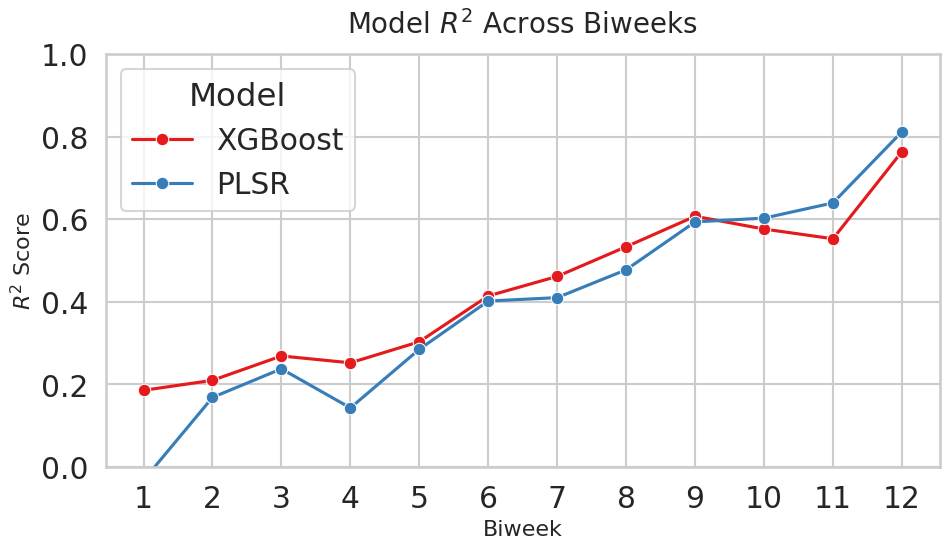

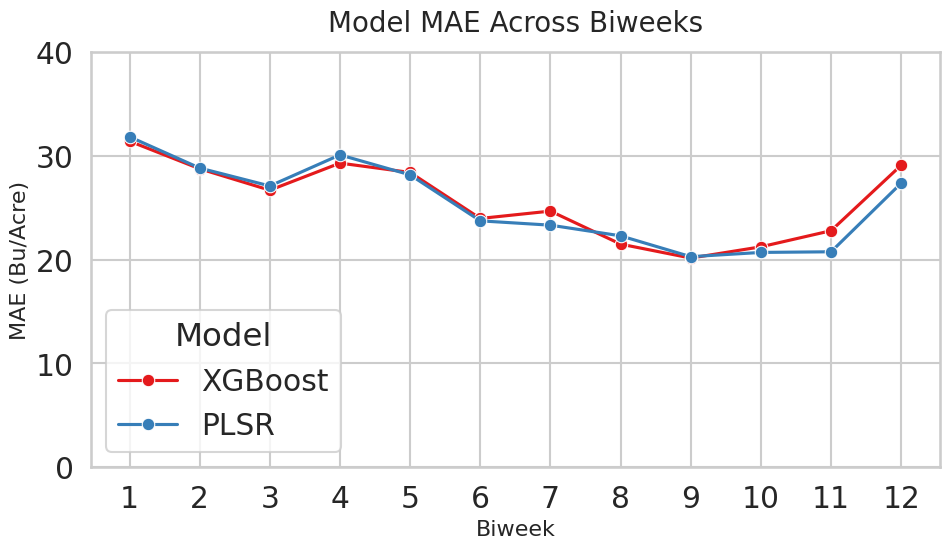

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

_code = "s12wd"  # Specify the code used in filenames
# Set seaborn style for publication
sns.set(style="whitegrid", context="talk", font_scale=1.3)

# Load results
df = pd.read_csv(f"classical_ml_results_{_code}.csv")
df["biweek_num"] = df["biweek"].str.extract(r"(\d+)").astype(int)
df['test_mae'] = df['test_mae'] * 370
# Prepare R² data
r2_long = df.melt(
    id_vars=["biweek_num", "model"],
    value_vars=["test_r2"],
    var_name="split",
    value_name="R²"
)
r2_long["split"] = r2_long["split"].str.replace("_r2", "").str.capitalize()

# Plot R²
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=r2_long,
    x="biweek_num",
    y="R²",
    hue="model",
    marker="o",
    palette="Set1"
)
plt.title("Model $R^2$ Across Biweeks", fontsize=20, pad=15)
plt.ylim(0.0, 1.0)
plt.xlabel("Biweek", fontsize=16)
plt.ylabel("$R^2$ Score", fontsize=16)
plt.xticks(df["biweek_num"].unique())
plt.legend(title="Model", loc="best")
plt.tight_layout()
plt.savefig("classical_ml_r2_biweek.pdf", bbox_inches="tight", dpi=300)
plt.show()

# Prepare MAE data
mae_long = df.melt(
    id_vars=["biweek_num", "model"],
    value_vars=["test_mae"],
    var_name="split",
    value_name="MAE"
)
mae_long["split"] = mae_long["split"].str.replace("_mae", "").str.capitalize()

# Plot MAE
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=mae_long,
    x="biweek_num",
    y="MAE",
    hue="model",
    marker="o",
    palette="Set1"
)
plt.title("Model MAE Across Biweeks", fontsize=20, pad=15)
plt.xlabel("Biweek", fontsize=16)
plt.ylabel("MAE (Bu/Acre)", fontsize=16)
plt.xticks(df["biweek_num"].unique())
plt.ylim(0, 40)
plt.legend(title="Model", loc="best")
plt.tight_layout()
plt.savefig("classical_ml_mae_biweek.pdf", bbox_inches="tight", dpi=300)
plt.show()